In [138]:
import numpy as np # linear algebra
import pandas as pd # data processing
import seaborn as sns # Plots
import matplotlib.pyplot as plt # Plots

# Logistic Regression and Model Metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report, accuracy_score

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Random Forest
from sklearn.ensemble import RandomForestClassifier


# PDP 
from sklearn.inspection import PartialDependenceDisplay

# SHAP
import shap

# LIME
from lime.lime_tabular import LimeTabularExplainer

from interpret.blackbox import LimeTabular
from interpret import show

# Vorlesungsbegleitendes Skript zu XAI

## Titanic Dataset


* Jede Zeile entspricht einem Passagier
* Wir bekommen einen ersten Überblick über die Datenstruktur
* Die Spalte Cabin enthält fehlende Werte NaN (Not a Number)

### Output Variable
Survived: 0 = Dead, 1 = Survived --> Output Variable

### Input Variablen (mögliche)
Pclass: Ticket class with 1 = 1st class, 2 = 2nd class, 3 = 3rd class

Sex: Gender of male or female

Age: Age in years

SibSp: Number of siblings/spouses aboard the Titanic

Parch: Number of parents/children aboard the Titanic

Ticket: Ticket number

Fare: Passenger fare (Preis)

Cabin: Cabin number

Embarked: Port of Embarkation with C = Cherbourg, Q = Queenstown, S = Southampton

In [86]:
# Datensatz laden
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [87]:
# Unerwünschte Spalten entfernen
# Wir entfernen z.B. 'deck', 'embark_town' (redundant zu 'embarked'), 'alive' (redundant zu 'survived'), 'class' (redundant zu 'pclass')
# Zudem 'who', 'adult_male', 'alone', da sie im Entscheidungsbaum nicht nützlich erscheinen
df_clean = df.drop(['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male', 'alone'], axis=1)

# Fehlende Werte für 'age', 'embarked' und 'fare' entfernen
df_clean = df_clean.dropna(subset=['age', 'embarked', 'fare'])

In [88]:
# Erzeugen von Dummy Variablen je kategorischer Variablen
df_clean = pd.get_dummies(df_clean, columns=['sex', 'embarked'], drop_first=True)
df_clean.head()

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [89]:
feature_names = df_clean.columns.tolist()
df_clean.head()

,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


# Machine Learning Modelle
## Train-Test-Split

In [90]:
# Input Variablen
X = df_clean.drop('survived', axis=1)
# Output Variable
y = df_clean['survived']

# Test und Trainingssplit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression

In [91]:
lr = LogisticRegression(random_state=0, max_iter=1000).fit(X_train, y_train)

# Modellanwendung auf Trainings- und Testdaten
y_pred_train_lr = lr.predict(X_train)
y_pred_lr = lr.predict(X_test)

print('Accuracy of Logistic Regression Train: ', accuracy_score(y_pred_train_lr, y_train))
print('Accuracy of Logistic Regression Test: ', accuracy_score(y_pred_lr, y_test))

print(lr.coef_)

Accuracy of Logistic Regression Train:  0.8084358523725835
Accuracy of Logistic Regression Test:  0.7972027972027972
[[-1.29521044e+00 -3.75915182e-02 -3.34913501e-01 -8.23397949e-04
  -5.50456190e-04 -2.57444167e+00 -3.90532496e-01 -2.20679863e-01]]


# Decision Tree

In [92]:
# Modelldefintion ohne Pruning und CV
dtc = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)

# Modellanwendung 
y_pred_train = dtc.predict(X_train)
y_pred = dtc.predict(X_test)

print('Accuracy of Decision Tree-Train: ', accuracy_score(y_pred_train, y_train))
print('Accuracy of Decision Tree-Test: ', accuracy_score(y_pred, y_test))


Accuracy of Decision Tree-Train:  0.9876977152899824
Accuracy of Decision Tree-Test:  0.7202797202797203


[Text(0.4091823340108401, 0.9736842105263158, 'x[5] <= 0.5\ngini = 0.478\nsamples = 569\nvalue = [344, 225]'),
 Text(0.1991869918699187, 0.9210526315789473, 'x[0] <= 2.5\ngini = 0.375\nsamples = 208\nvalue = [52, 156]'),
 Text(0.3041846629403794, 0.9473684210526316, 'True  '),
 Text(0.13279132791327913, 0.868421052631579, 'x[1] <= 56.5\ngini = 0.105\nsamples = 126\nvalue = [7, 119]'),
 Text(0.12195121951219512, 0.8157894736842105, 'x[4] <= 28.856\ngini = 0.091\nsamples = 125\nvalue = [6, 119]'),
 Text(0.0921409214092141, 0.7631578947368421, 'x[4] <= 28.231\ngini = 0.163\nsamples = 56\nvalue = [5, 51]'),
 Text(0.08130081300813008, 0.7105263157894737, 'x[1] <= 27.5\ngini = 0.135\nsamples = 55\nvalue = [4, 51]'),
 Text(0.05420054200542006, 0.6578947368421053, 'x[1] <= 25.5\ngini = 0.245\nsamples = 21\nvalue = [3, 18]'),
 Text(0.032520325203252036, 0.6052631578947368, 'x[4] <= 13.396\ngini = 0.111\nsamples = 17\nvalue = [1, 16]'),
 Text(0.02168021680216802, 0.5526315789473685, 'x[1] <= 20.

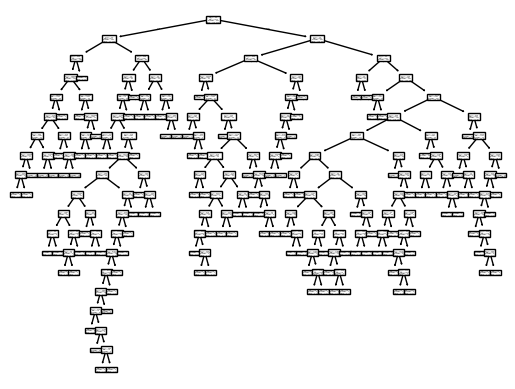

In [93]:
# Plot tree
plot_tree(dtc)

Bestes ccp_alpha durch Cross-Validation: 0.0025155932320204007
Genauigkeit des besten Modells auf dem Testdatensatz: 0.7343


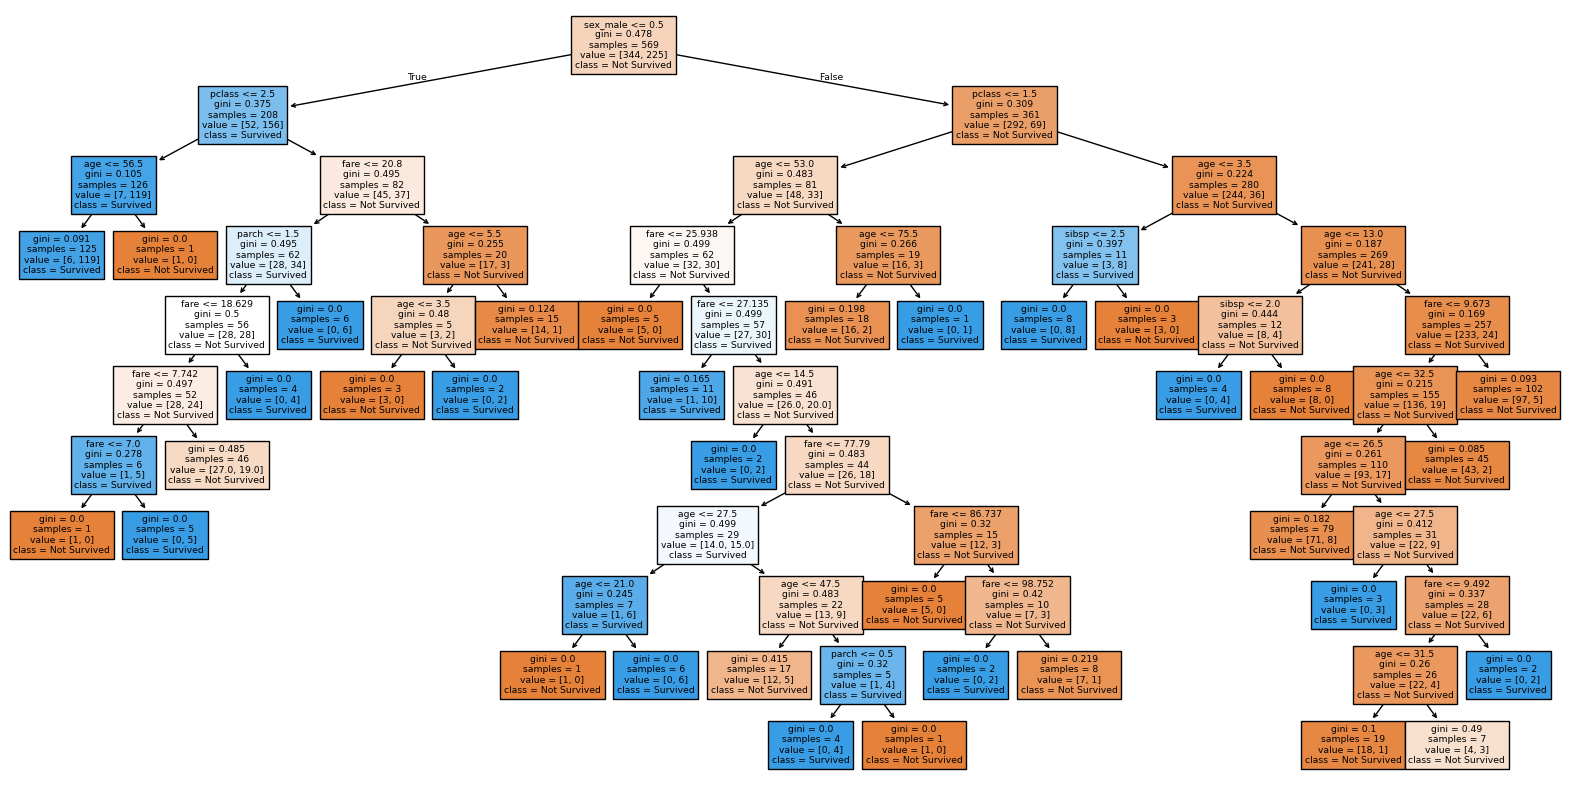

In [94]:
# Ermittlung aller ccp_alpha-Werte durch den Pruning-Pfad
path = dtc.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Verwendung von GridSearchCV zur Bestimmung des besten ccp_alpha-Werts
param_grid = {'ccp_alpha': ccp_alphas}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Das beste ccp_alpha ermitteln
best_ccp_alpha = grid_search.best_params_['ccp_alpha']
print(f"Bestes ccp_alpha durch Cross-Validation: {best_ccp_alpha}")

# Modell mit dem besten ccp_alpha trainieren
best_dtc = DecisionTreeClassifier(random_state=42, ccp_alpha=best_ccp_alpha)
best_dtc.fit(X_train, y_train)

# Vorhersagen und Genauigkeit auf den Testdaten
y_pred = best_dtc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Genauigkeit des besten Modells auf dem Testdatensatz: {accuracy:.4f}")

# Entscheidungsbaum des besten Modells visualisieren
plt.figure(figsize=(20, 10))
plot_tree(best_dtc, filled=True, feature_names=X.columns, class_names=["Not Survived", "Survived"])
plt.show()

# Random Forest

In [95]:
rf = RandomForestClassifier(n_estimators=1000, max_depth=5, min_samples_split=2, min_samples_leaf=5, random_state=0)
rf.fit(X_train, y_train)

# Modellanwendung 
y_pred_train_rf = rf.predict(X_train)
y_pred_rf = rf.predict(X_test)

print('Accuracy of Random Forest-Train: ', accuracy_score(y_pred_train_rf, y_train))
print('Accuracy of Random Forest-Test: ', accuracy_score(y_pred_rf, y_test))




Accuracy of Random Forest-Train:  0.8576449912126538
Accuracy of Random Forest-Test:  0.8041958041958042


In [97]:
# Grid Search für Hyperparameter-Tuning
param_grid = {
    'n_estimators': [100, 500, 1000],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}
GridSearch = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=0)
GridSearch.fit(X_train, y_train)
print(GridSearch.best_params_)

rf = RandomForestClassifier(max_depth=GridSearch.best_params_['max_depth'], min_samples_leaf=GridSearch.best_params_['min_samples_leaf'], 
    min_samples_split=GridSearch.best_params_['min_samples_split'], n_estimators=GridSearch.best_params_['n_estimators'], random_state=0)
rf.fit(X_train, y_train)

# Modellanwendung 
y_pred_train_rf = rf.predict(X_train)
y_pred_rf = rf.predict(X_test)

print('Accuracy of Random Forest-Train: ', accuracy_score(y_pred_train_rf, y_train))
print('Accuracy of Random Forest-Test: ', accuracy_score(y_pred_rf, y_test))

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Accuracy of Random Forest-Train:  0.9086115992970123
Accuracy of Random Forest-Test:  0.7902097902097902


## SHAP

     pclass   age  sibsp  parch     fare  sex_male  embarked_Q  embarked_S
496       1  54.0      1      0  78.2667         0           0           0
496    1
Name: survived, dtype: int64
[[[-0.13224296  0.13224296]
  [ 0.06686233 -0.06686233]
  [-0.03743812  0.03743812]
  [ 0.00243563 -0.00243563]
  [-0.10199147  0.10199147]
  [-0.26897171  0.26897171]
  [-0.00057308  0.00057308]
  [-0.03581735  0.03581735]]]


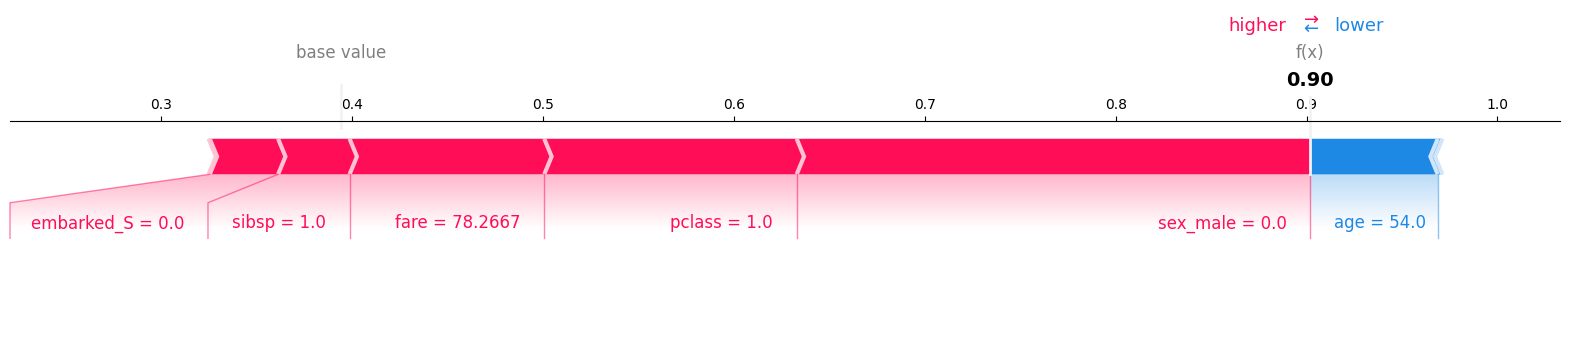

In [ ]:
# Individuelle/Lokale Erklärbarkeit (einzelne Beobachtung)
# SHAP Explainer
explainer = shap.TreeExplainer(rf) # Anzahl der zu berechnenden Kombinationen von Subsets optimiert für Random Forest Modelle
# Shapely Values for Test data
start_index = 1
end_index = 2
shap_values = explainer.shap_values(X_test[start_index:end_index])
print(X_test[start_index:end_index]) # Ein Beispiel aus den Testdaten - eine Beobachtung
print(y_test[start_index:end_index]) # Das tatsächliche Label der Beobachtung

print(shap_values) # Shapely Values für die Beobachtung (jede Spalte entspricht einer Ausprägung der Zielvariablen)

shap.force_plot(explainer.expected_value[1], shap_values[0][:,1] , X_test[start_index:end_index], matplotlib=True)

     pclass   age  sibsp  parch   fare  sex_male  embarked_Q  embarked_S
262       1  52.0      1      1  79.65         1           0           1
262    0
Name: survived, dtype: int64
[[[-0.11197653  0.11197653]
  [ 0.00735263 -0.00735263]
  [-0.03278125  0.03278125]
  [ 0.02053525 -0.02053525]
  [-0.09722727  0.09722727]
  [ 0.19216915 -0.19216915]
  [-0.00024119  0.00024119]
  [ 0.00657887 -0.00657887]]]


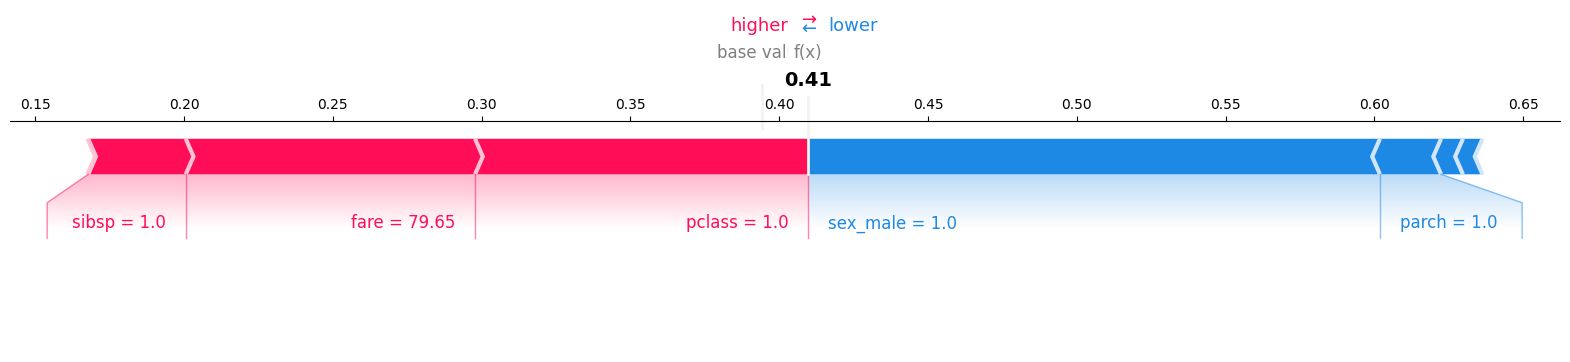

In [105]:
# Individuelle/Lokale Erklärbarkeit (einzelne Beobachtung)
# SHAP Explainer
explainer = shap.TreeExplainer(rf) # Anzahl der zu berechnenden Kombinationen von Subsets optimiert für Random Forest Modelle
# Shapely Values for Test data
start_index = 2
end_index = 3
shap_values = explainer.shap_values(X_test[start_index:end_index])
print(X_test[start_index:end_index]) # Ein Beispiel aus den Testdaten - eine Beobachtung
print(y_test[start_index:end_index]) # Das tatsächliche Label der Beobachtung

print(shap_values) # Shapely Values für die Beobachtung (jede Spalte entspricht einer Ausprägung der Zielvariablen)

shap.force_plot(explainer.expected_value[1], shap_values[0][:,1] , X_test[start_index:end_index], matplotlib=True)

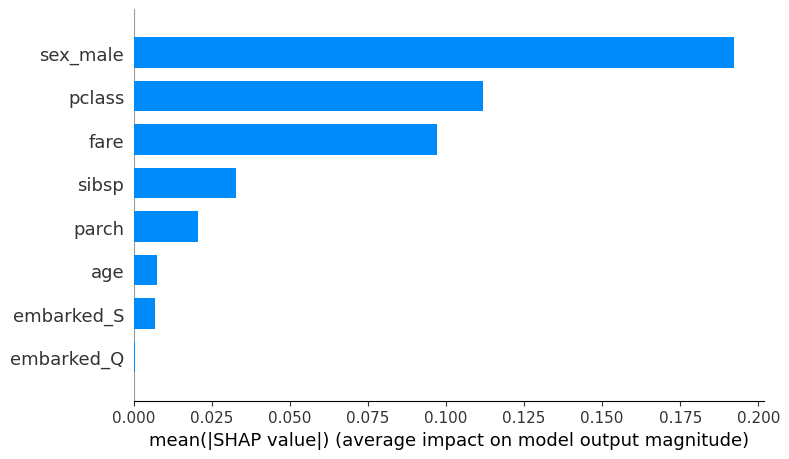

In [118]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar", max_display=10) # globale Erklärung - Shap Werte für mehrere Beobachtungen

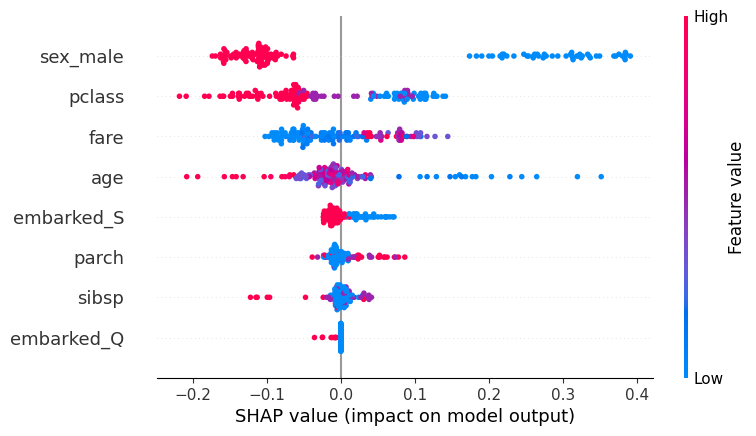

In [104]:
# Nachteil von PDP - Mittelwert über alle Beobachtungen, es kann sein, dass eine Variable einen großen Einfluss auf eine Beobachtung hat, jedoch nicht auf andere

bool_features = [
    "sex_male",
    "embarked_Q",
    "embarked_S"
]

X_train[bool_features] = (
    X_train[bool_features]
    .astype(int)
)

X_test[bool_features] = (
    X_test[bool_features]
    .astype(int)
)

background = X_train.sample(
    n=min(100, len(X_train)),
    random_state=42
)

explainer = shap.TreeExplainer( # TreeExplainer speziell für Baumbasierte Modelle - genau genommen nicht mehr Modell-agnostisch!, allemein: shap.Explainer
    model=rf,
    data=background,
    feature_perturbation="interventional",
    model_output="probability"
)

shap_values = explainer(X_test)

shap_survived = shap_values[:, :, 1]
shap.plots.beeswarm(shap_survived)

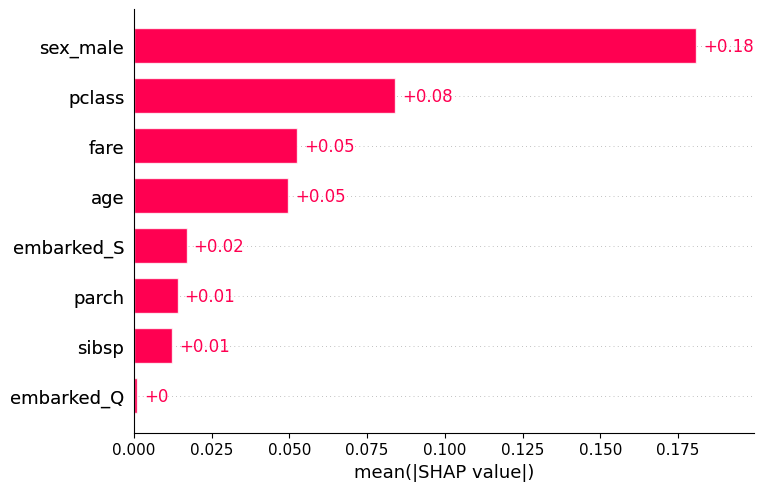

In [ ]:
shap.plots.bar(
    shap_survived,
    max_display=8
)

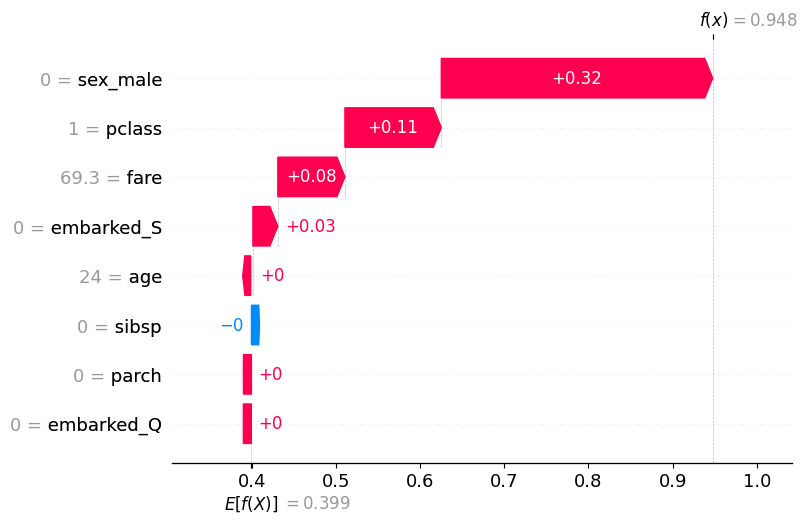

In [ ]:
shap.plots.waterfall(
    shap_survived[0]
)

## LIME

In [130]:
# LIME Explainer
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Not Survived", "Survived"],
    mode="classification"
)

lime_local = explainer.explain_instance(X_test.iloc[0].values, rf.predict_proba, num_features=5)
print(lime_local.as_list())

[('sex_male <= 0.00', 0.4049994998366937), ('pclass <= 1.00', 0.13360250260741158), ('fare > 31.00', 0.09751772957886512), ('parch <= 0.00', -0.02855189762651863), ('21.00 < age <= 28.00', -0.013654707864455747)]


In [131]:
class_names = [str(c) for c in rf.classes_]
feature_names = X_test.columns.tolist()


categorical_feature_names = [
    col for col in ["pclass", "sex_male", "embarked_Q", "embarked_S"]
    if col in feature_names
]

categorical_features = [
    feature_names.index(col) for col in categorical_feature_names
]

categorical_names = {}

if "pclass" in feature_names:
    categorical_names[feature_names.index("pclass")] = ["1", "2", "3"]

if "sex_male" in feature_names:
    categorical_names[feature_names.index("sex_male")] = ["female", "male"]

if "embarked_Q" in feature_names:
    categorical_names[feature_names.index("embarked_Q")] = ["not Q", "Q"]

if "embarked_S" in feature_names:
    categorical_names[feature_names.index("embarked_S")] = ["not S", "S"]

print("Categorical features:", categorical_feature_names)

explainer = LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=feature_names,
    class_names=class_names,
    categorical_features=categorical_features,
    categorical_names=categorical_names,
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

x0 = X_test.iloc[0].values
pred = rf.predict_proba(pd.DataFrame([x0], columns=feature_names))[0]
print("\nBeobachtung:")
print(x0)
print("\nVorhergesagte Wahrscheinlichkeiten:", dict(zip(class_names, pred)))

# Bei Titanic üblicherweise: Klassen [0, 1]
# Wir erklären die Klasse survived=1, falls vorhanden.
if 1 in list(rf.classes_):
    label_to_explain = list(rf.classes_).index(1)
else:
    label_to_explain = 1

exp = explainer.explain_instance(
    X_test.iloc[0].values,
    rf.predict_proba,
    labels=[label_to_explain],
    num_features=8,
    num_samples=5000
)

print("\nLIME Erklärung für Klasse", class_names[label_to_explain])
print(exp.as_list(label=label_to_explain))


Categorical features: ['pclass', 'sex_male', 'embarked_Q', 'embarked_S']

Beobachtung:
[ 1.  24.   0.   0.  69.3  0.   0.   0. ]

Vorhergesagte Wahrscheinlichkeiten: {'0': np.float64(0.052378905408317175), '1': np.float64(0.9476210945916829)}

LIME Erklärung für Klasse 1
[('sex_male=female', 0.3977457162255544), ('pclass=2', 0.1486371402600093), ('fare > 31.00', 0.0981357993051796), ('embarked_S=not S', 0.03175128656001988), ('parch <= 0.00', -0.03074688769482472), ('21.00 < age <= 28.00', -0.015094380160265156), ('sibsp <= 0.00', 0.008285034196180525), ('embarked_Q=not Q', 0.004009340552099195)]


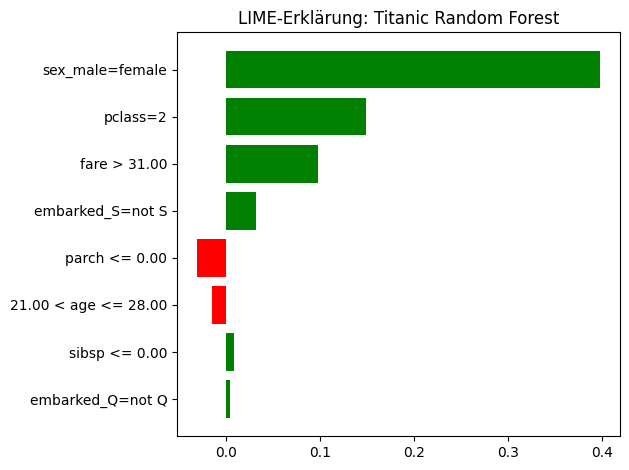

In [132]:
fig = exp.as_pyplot_figure(label=label_to_explain)
plt.title("LIME-Erklärung: Titanic Random Forest")
plt.tight_layout()
plt.show()

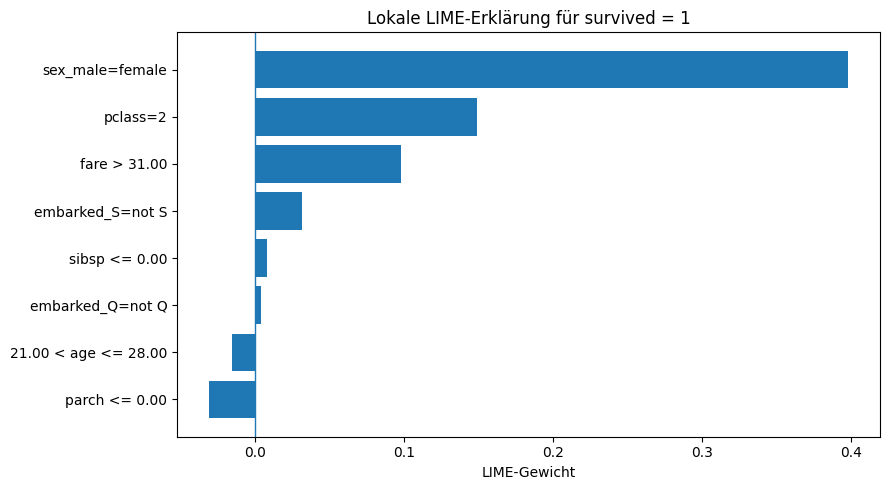

In [133]:
lime_list = exp.as_list(label=label_to_explain)

lime_df = pd.DataFrame(lime_list, columns=["feature_rule", "lime_weight"])
lime_df = lime_df.sort_values("lime_weight")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(lime_df["feature_rule"], lime_df["lime_weight"])
ax.axvline(0, linewidth=1)
ax.set_xlabel("LIME-Gewicht")
ax.set_title("Lokale LIME-Erklärung für survived = 1")
plt.tight_layout()
plt.show()

In [135]:
example_indices = [2,3]

rows = []

for idx in example_indices:
    x_i = X_test.iloc[idx]
    exp_i = explainer.explain_instance(
        data_row=x_i.to_numpy(),
        predict_fn=rf.predict_proba,
        labels=[label_to_explain],
        num_features=8,
        num_samples=5000,
    )

    pred_i = rf.predict_proba(pd.DataFrame([x_i], columns=feature_names))[0, label_to_explain]

    for feature_rule, weight in exp_i.as_list(label=label_to_explain):
        rows.append({
            "test_index": X_test.index[idx],
            "pred_survived_1": pred_i,
            "feature_rule": feature_rule,
            "lime_weight": weight,
        })

lime_compare = pd.DataFrame(rows)
print("\nVergleich mehrerer lokaler LIME-Erklärungen:")
print(lime_compare)



Vergleich mehrerer lokaler LIME-Erklärungen:
    test_index  pred_survived_1          feature_rule  lime_weight
0          262         0.409738         sex_male=male    -0.402723
1          262         0.409738              pclass=2     0.131533
2          262         0.409738          fare > 31.00     0.096843
3          262         0.409738           age > 38.00    -0.060554
4          262         0.409738          embarked_S=S    -0.034700
5          262         0.409738  0.00 < parch <= 1.00     0.014900
6          262         0.409738      embarked_Q=not Q     0.005475
7          262         0.409738  0.00 < sibsp <= 1.00     0.000712
8          311         0.879346       sex_male=female     0.388363
9          311         0.879346              pclass=2     0.140440
10         311         0.879346          fare > 31.00     0.096927
11         311         0.879346          age <= 21.00     0.075333
12         311         0.879346      embarked_S=not S     0.041953
13         311  

In [144]:
lime = LimeTabular(rf, 
                   data=X_train, 
                   random_state=1)
# Get local explanations
lime_local = lime.explain_local(X_test[-20:], 
                                y_test[-20:], 
                                name='LIME')

show(lime_local)


<!-- http://127.0.0.1:7001/4853146224/ -->